In [42]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

install imbalanced learn

In [43]:
!pip install imbalanced-learn

Load dataset

In [44]:
df = pd.read_csv("/content/creditcard.csv")

In [45]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [47]:
df.shape

(89220, 31)

In [48]:
print(df["Class"].value_counts(dropna=False))

Class
0.0    89008
1.0      211
NaN        1
Name: count, dtype: int64


In [50]:
df = df.dropna(subset=["Class"])

In [51]:
print(df["Class"].value_counts(dropna=False))

Class
0.0    89008
1.0      211
Name: count, dtype: int64


In [52]:
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89219 entries, 0 to 89218
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    89219 non-null  int64  
 1   V1      89219 non-null  float64
 2   V2      89219 non-null  float64
 3   V3      89219 non-null  float64
 4   V4      89219 non-null  float64
 5   V5      89219 non-null  float64
 6   V6      89219 non-null  float64
 7   V7      89219 non-null  float64
 8   V8      89219 non-null  float64
 9   V9      89219 non-null  float64
 10  V10     89219 non-null  float64
 11  V11     89219 non-null  float64
 12  V12     89219 non-null  float64
 13  V13     89219 non-null  float64
 14  V14     89219 non-null  float64
 15  V15     89219 non-null  float64
 16  V16     89219 non-null  float64
 17  V17     89219 non-null  float64
 18  V18     89219 non-null  float64
 19  V19     89219 non-null  float64
 20  V20     89219 non-null  float64
 21  V21     89219 non-null  float64
 22  V22

In [54]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,89219.000000,89219.000000,89219.000000,89219.000000,89219.000000,89219.000000,89219.000000,89219.000000,89219.000000,89219.000000,...,89219.000000,89219.000000,89219.000000,89219.000000,89219.000000,89219.000000,89219.000000,89219.000000,89219.000000,89219.000000
mean,39714.760343,-0.265017,-0.039310,0.678741,0.162818,-0.278288,0.094285,-0.109560,0.054700,-0.028905,...,-0.029895,-0.106761,-0.037413,0.009718,0.132571,0.027095,0.001317,0.002412,98.532339,0.002365
std,16026.394409,1.873462,1.662189,1.352998,1.359528,1.370156,1.302137,1.230888,1.215542,1.129755,...,0.727551,0.634882,0.625389,0.594412,0.441100,0.496667,0.389659,0.326436,266.941369,0.048574
min,0.000000,-56.407510,-72.715728,-33.680984,-5.172595,-42.147898,-26.160506,-31.764946,-73.216718,-9.283925,...,-34.830382,-10.933144,-26.751119,-2.836627,-7.495741,-2.534330,-9.390980,-9.617915,0.000000,0.000000
25%,32165.000000,-1.028785,-0.603276,0.182846,-0.719040,-0.897379,-0.646344,-0.601124,-0.139872,-0.692643,...,-0.223859,-0.526395,-0.177767,-0.322006,-0.131948,-0.325915,-0.063273,-0.005744,7.675000,0.000000
50%,42017.000000,-0.262228,0.071695,0.760389,0.185850,-0.313066,-0.156192,-0.070829,0.071465,-0.102804,...,-0.057810,-0.082239,-0.049619,0.064928,0.171090,-0.070776,0.009396,0.023123,26.990000,0.000000
75%,52274.000000,1.152737,0.727352,1.386560,1.037571,0.254273,0.489005,0.416677,0.355078,0.589973,...,0.118714,0.309107,0.081203,0.406088,0.420191,0.306496,0.082733,0.076409,89.950000,0.000000
max,62480.000000,1.960497,18.902453,4.226108,16.715537,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,10.503090,18.946734,4.014444,5.525093,3.517346,12.152401,33.847808,19656.530000,1.000000


In [55]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Check Fraud Distribution

In [56]:
df['Class'].value_counts()

,count
Class,
0.0,89008
1.0,211


Visualize Class Distribution

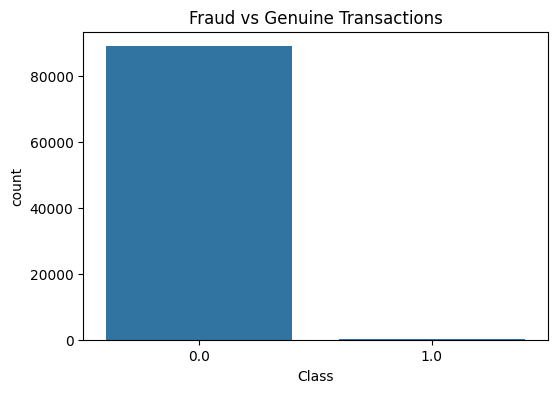

In [57]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

Corelation Heatmap

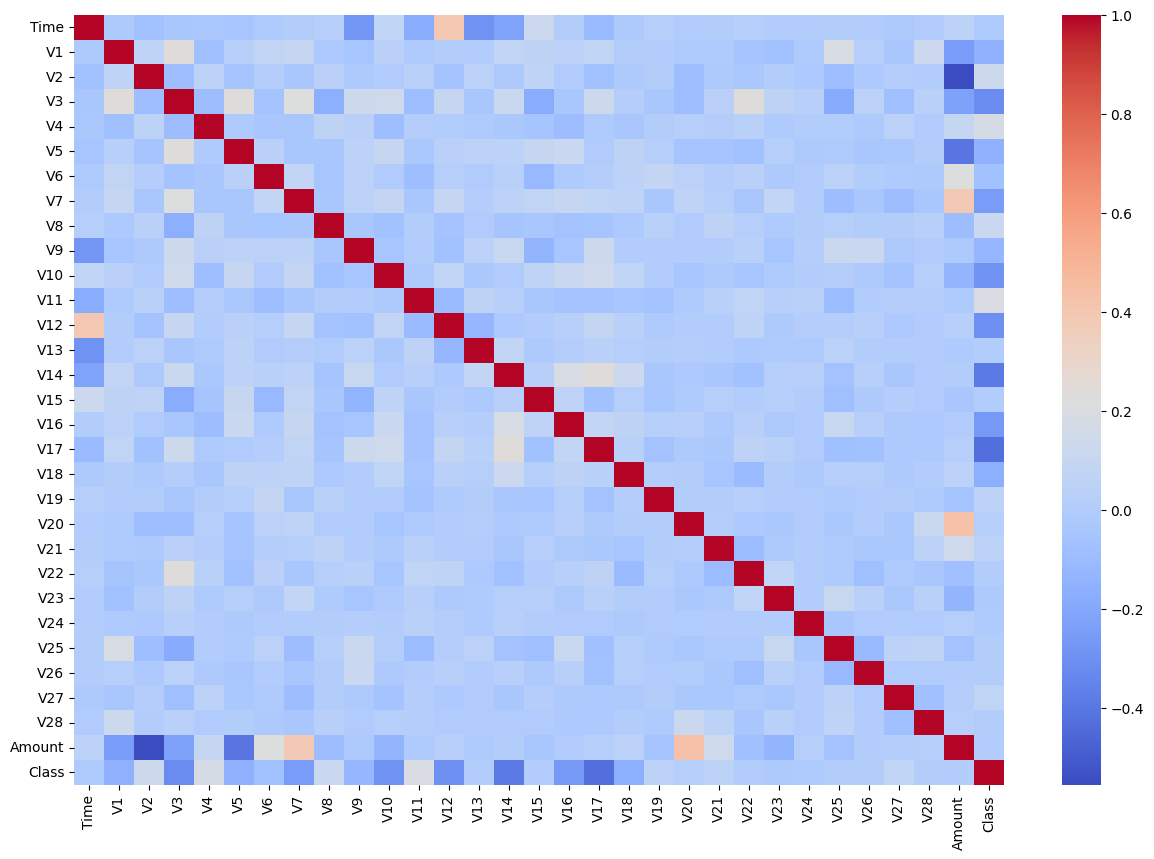

In [58]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

Normalize amount Coloumn

In [59]:
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])

Drop Time Coloumn

In [60]:
df.drop("Time", axis=1, inplace=True)

Seprate Feature & Target

In [62]:
X = df.drop("Class", axis=1)
y = df["Class"]

Train Test Split

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [64]:
print(y_train.value_counts())

Class
0.0    71206
1.0      169
Name: count, dtype: int64


Apply SMOTE

SMOTE generates synthetic fraud samples.

In [65]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

Train Logistic Regression

In [66]:
lr = LogisticRegression()

lr.fit(X_train_smote, y_train_smote)

LogisticRegression()

Prediction

In [68]:
y_pred_lr = lr.predict(X_test)


Evaluation

In [69]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))

print("Precision :", precision_score(y_test, y_pred_lr))

print("Recall :", recall_score(y_test, y_pred_lr))

print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.9787043263842188
Precision : 0.09375
Recall : 0.9285714285714286
F1 Score : 0.1703056768558952


Classification Report

In [70]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     17802
         1.0       0.09      0.93      0.17        42

    accuracy                           0.98     17844
   macro avg       0.55      0.95      0.58     17844
weighted avg       1.00      0.98      0.99     17844



Confusion Matrix

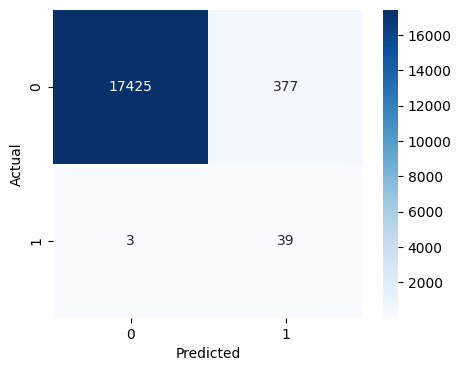

In [71]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Random Forest model

In [72]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

Prediction

In [73]:
y_pred_rf = rf.predict(X_test)

Evalution

In [74]:
print("Accuracy :", accuracy_score(y_test,y_pred_rf))

print("Precision :", precision_score(y_test,y_pred_rf))

print("Recall :", recall_score(y_test,y_pred_rf))

print("F1 Score :", f1_score(y_test,y_pred_rf))

Accuracy : 0.9993835462900695
Precision : 0.8780487804878049
Recall : 0.8571428571428571
F1 Score : 0.8674698795180723


Classificatiion Report

In [75]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     17802
         1.0       0.88      0.86      0.87        42

    accuracy                           1.00     17844
   macro avg       0.94      0.93      0.93     17844
weighted avg       1.00      1.00      1.00     17844



Confusion Matrix

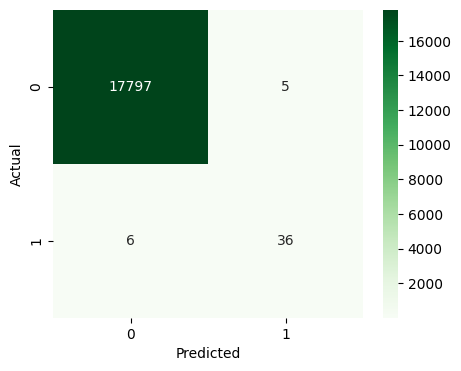

In [76]:
cm = confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            cmap='Greens',
            fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Compare Models

In [77]:
comparison = pd.DataFrame({

    "Model":["Logistic Regression","Random Forest"],

    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf)
    ],

    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf)
    ],

    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.978704,0.093750,0.928571,0.170306
1,Random Forest,0.999384,0.878049,0.857143,0.867470


Bar Graph Comparison

In [78]:
comparison = pd.DataFrame({

    "Model":["Logistic Regression","Random Forest"],

    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf)
    ],

    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf)
    ],

    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.978704,0.093750,0.928571,0.170306
1,Random Forest,0.999384,0.878049,0.857143,0.867470


Save Model

In [79]:
import joblib

joblib.dump(rf,"credit_card_fraud_model.pkl")

['credit_card_fraud_model.pkl']

Load Model

In [80]:
model = joblib.load("credit_card_fraud_model.pkl")